In [1]:
from pathlib import Path
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
project_root = Path.cwd().parent

input_path = project_root / "data" / "raw" / "clean" / "paddleocr_demo.png"

output_dir = project_root / "results" / "images"

output_dir.mkdir(parents=True, exist_ok=True)

print("Project:", project_root)
print("Input:", input_path)
print("Output:", output_dir)

Project: D:\mycode\GlyphForge
Input: D:\mycode\GlyphForge\data\raw\clean\paddleocr_demo.png
Output: D:\mycode\GlyphForge\results\images


In [3]:
image = cv2.imread(str(input_path))

if image is None:
    raise FileNotFoundError(f"Could not load image: {input_path}")

print("Loaded:", input_path.name)
print("Shape:", image.shape)
print("Dtype:", image.dtype)

Loaded: paddleocr_demo.png
Shape: (1368, 1524, 3)
Dtype: uint8


In [4]:
height, width, channels = image.shape

file_size_bytes = input_path.stat().st_size
pixel_count = width * height

print("Width:", width)
print("Height:", height)
print("Channels:", channels)
print("Pixels:", pixel_count)
print("File size:", round(file_size_bytes / 1024, 2), "KB")

Width: 1524
Height: 1368
Channels: 3
Pixels: 2084832
File size: 2272.24 KB


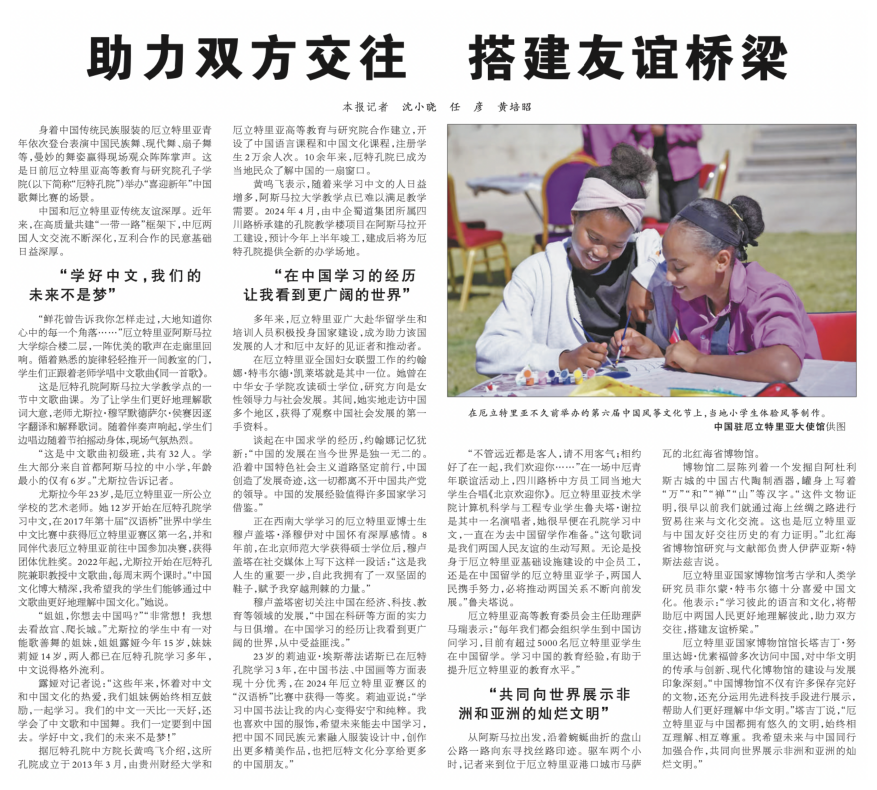

In [5]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 10))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [6]:
b, g, r = cv2.split(image)

print("Blue mean:", round(float(b.mean()), 2))
print("Green mean:", round(float(g.mean()), 2))
print("Red mean:", round(float(r.mean()), 2))

Blue mean: 216.33
Green mean: 216.02
Red mean: 218.9


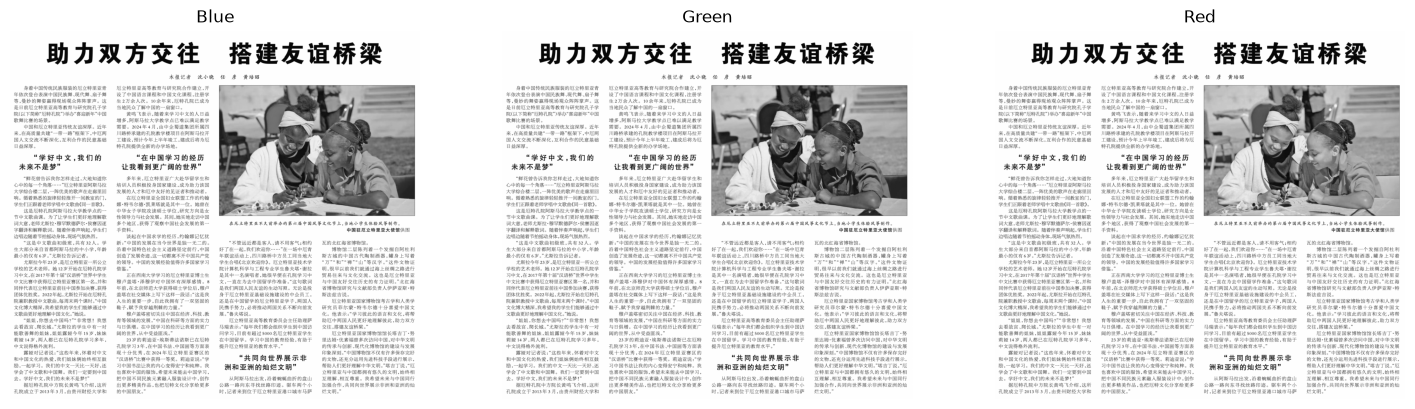

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(b, cmap="gray")
axes[0].set_title("Blue")
axes[0].axis("off")

axes[1].imshow(g, cmap="gray")
axes[1].set_title("Green")
axes[1].axis("off")

axes[2].imshow(r, cmap="gray")
axes[2].set_title("Red")
axes[2].axis("off")

plt.show()

In [8]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("Original shape:", image.shape)
print("Grayscale shape:", gray.shape)
print("Grayscale dtype:", gray.dtype)

Original shape: (1368, 1524, 3)
Grayscale shape: (1368, 1524)
Grayscale dtype: uint8


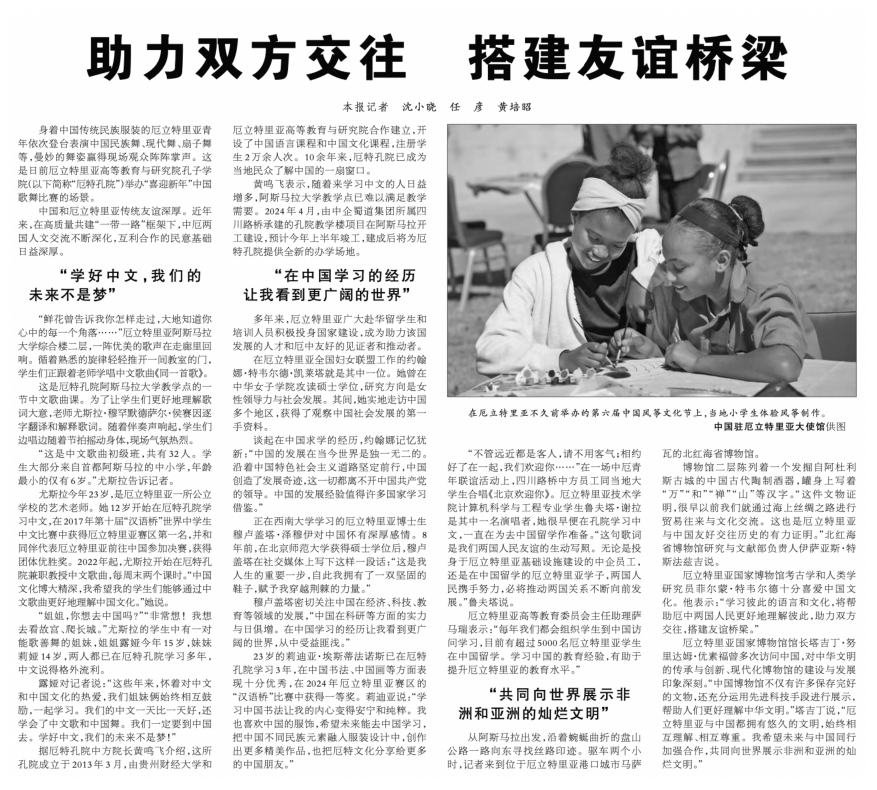

In [9]:
plt.figure(figsize=(14, 10))
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

In [10]:
gray_path = output_dir / "paddleocr_demo_grayscale.png"

cv2.imwrite(str(gray_path), gray)

print(gray_path)
print(round(gray_path.stat().st_size / 1024, 2), "KB")

D:\mycode\GlyphForge\results\images\paddleocr_demo_grayscale.png
851.49 KB


In [11]:
print("Minimum:", int(gray.min()))
print("Maximum:", int(gray.max()))
print("Mean:", round(float(gray.mean()), 2))
print("Standard deviation:", round(float(gray.std()), 2))

Minimum: 19
Maximum: 255
Mean: 216.91
Standard deviation: 64.66


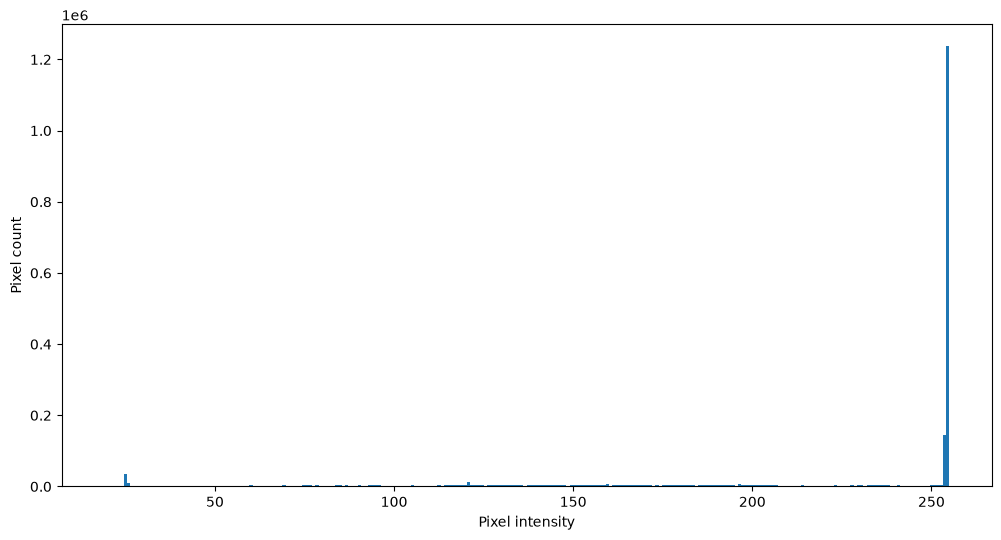

In [12]:
plt.figure(figsize=(12, 6))
plt.hist(gray.ravel(), bins=256)
plt.xlabel("Pixel intensity")
plt.ylabel("Pixel count")
plt.show()

In [13]:
otsu_threshold, binary_otsu = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Otsu threshold:", otsu_threshold)

Otsu threshold: 178.0


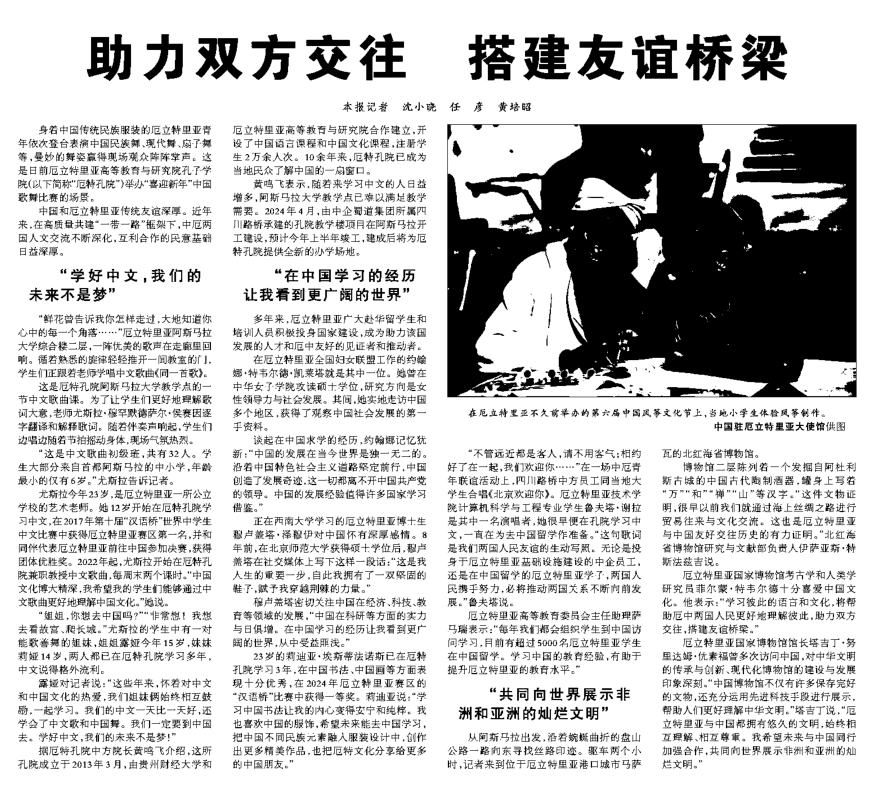

In [14]:
plt.figure(figsize=(14, 10))
plt.imshow(binary_otsu, cmap="gray")
plt.axis("off")
plt.show()

In [15]:
otsu_path = output_dir / "paddleocr_demo_otsu.png"

cv2.imwrite(str(otsu_path), binary_otsu)

print(otsu_path)
print(round(otsu_path.stat().st_size / 1024, 2), "KB")

D:\mycode\GlyphForge\results\images\paddleocr_demo_otsu.png
142.61 KB


In [16]:
binary_adaptive = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    31,
    10
)

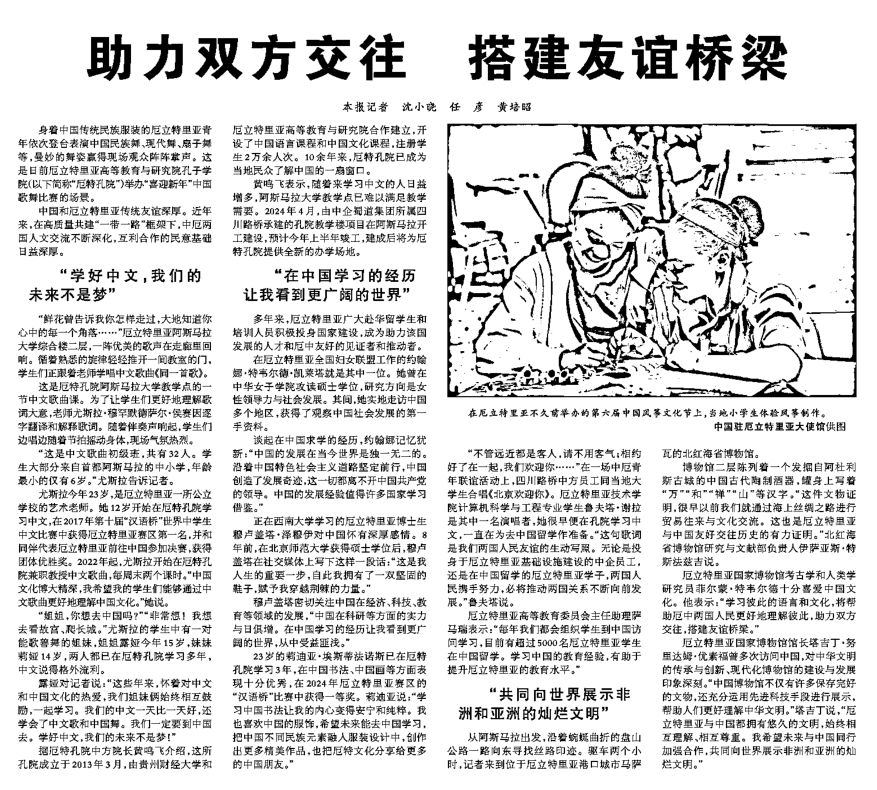

In [17]:
plt.figure(figsize=(14, 10))
plt.imshow(binary_adaptive, cmap="gray")
plt.axis("off")
plt.show()

In [18]:
adaptive_path = output_dir / "paddleocr_demo_adaptive.png"

cv2.imwrite(str(adaptive_path), binary_adaptive)

print(adaptive_path)
print(round(adaptive_path.stat().st_size / 1024, 2), "KB")

D:\mycode\GlyphForge\results\images\paddleocr_demo_adaptive.png
159.79 KB


In [19]:
results = pd.DataFrame([
    {
        "method": "original",
        "path": input_path,
        "size_bytes": input_path.stat().st_size
    },
    {
        "method": "grayscale",
        "path": gray_path,
        "size_bytes": gray_path.stat().st_size
    },
    {
        "method": "otsu",
        "path": otsu_path,
        "size_bytes": otsu_path.stat().st_size
    },
    {
        "method": "adaptive",
        "path": adaptive_path,
        "size_bytes": adaptive_path.stat().st_size
    }
])

results["size_kb"] = results["size_bytes"] / 1024

results

,method,path,size_bytes,size_kb
0,original,D:\mycode\GlyphForge\data\raw\clean\paddleocr_...,2326771,2272.237305
1,grayscale,D:\mycode\GlyphForge\results\images\paddleocr_...,871922,851.486328
2,otsu,D:\mycode\GlyphForge\results\images\paddleocr_...,146031,142.608398
3,adaptive,D:\mycode\GlyphForge\results\images\paddleocr_...,163624,159.789062


In [20]:
original_size = results.loc[
    results["method"] == "original",
    "size_bytes"
].iloc[0]

results["compression_ratio"] = original_size / results["size_bytes"]

results

,method,path,size_bytes,size_kb,compression_ratio
0,original,D:\mycode\GlyphForge\data\raw\clean\paddleocr_...,2326771,2272.237305,1.000000
1,grayscale,D:\mycode\GlyphForge\results\images\paddleocr_...,871922,851.486328,2.668554
2,otsu,D:\mycode\GlyphForge\results\images\paddleocr_...,146031,142.608398,15.933405
3,adaptive,D:\mycode\GlyphForge\results\images\paddleocr_...,163624,159.789062,14.220231


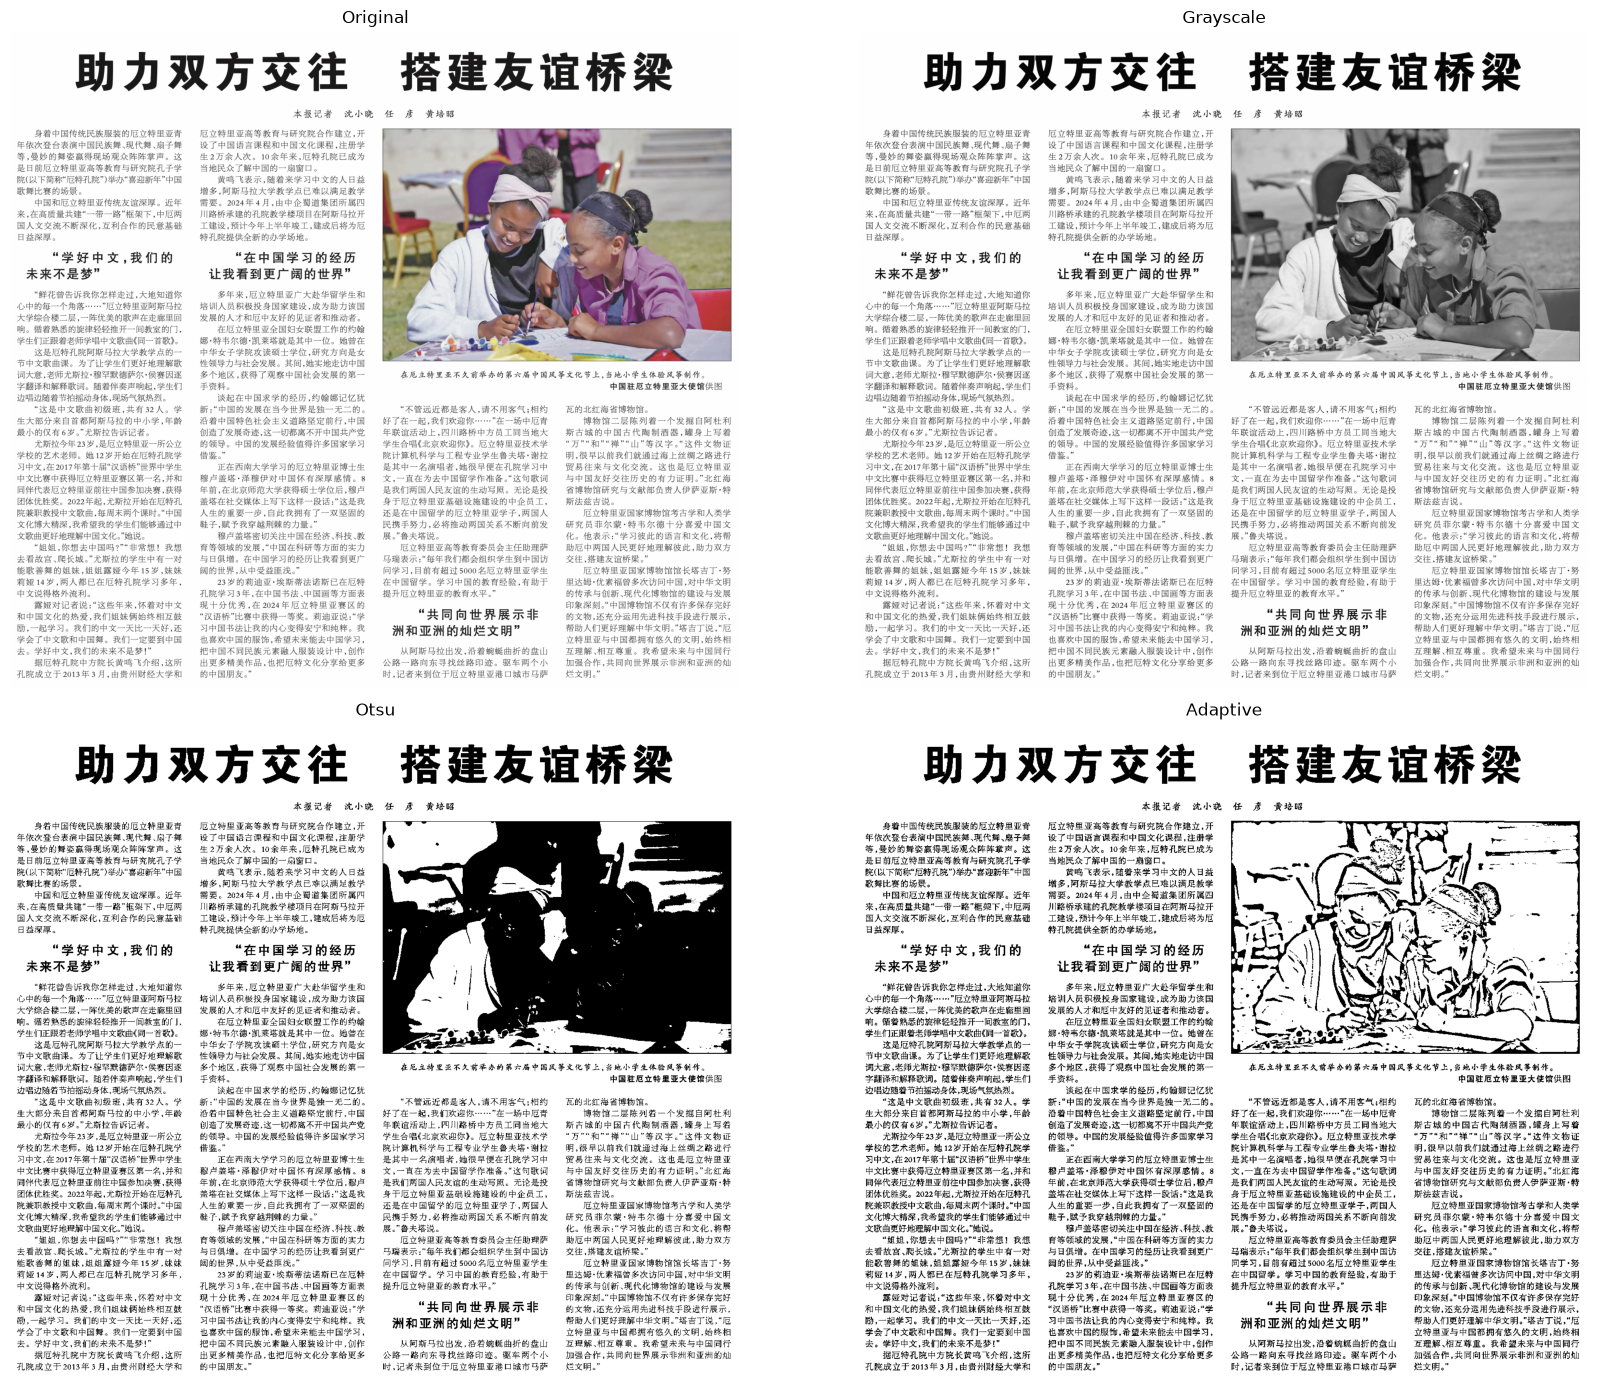

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

axes[0, 0].imshow(image_rgb)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

axes[0, 1].imshow(gray, cmap="gray")
axes[0, 1].set_title("Grayscale")
axes[0, 1].axis("off")

axes[1, 0].imshow(binary_otsu, cmap="gray")
axes[1, 0].set_title("Otsu")
axes[1, 0].axis("off")

axes[1, 1].imshow(binary_adaptive, cmap="gray")
axes[1, 1].set_title("Adaptive")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

In [22]:
baseline = results[
    ["method", "size_kb", "compression_ratio"]
].copy()

baseline

,method,size_kb,compression_ratio
0,original,2272.237305,1.000000
1,grayscale,851.486328,2.668554
2,otsu,142.608398,15.933405
3,adaptive,159.789062,14.220231


In [23]:
baseline_path = project_root / "results" / "benchmarks" / "image_baseline.csv"

baseline.to_csv(baseline_path, index=False)

print(baseline_path)

D:\mycode\GlyphForge\results\benchmarks\image_baseline.csv


In [24]:
saved_images = [
    gray_path,
    otsu_path,
    adaptive_path
]

for path in saved_images:
    print(path.name, path.exists(), round(path.stat().st_size / 1024, 2), "KB")

paddleocr_demo_grayscale.png True 851.49 KB
paddleocr_demo_otsu.png True 142.61 KB
paddleocr_demo_adaptive.png True 159.79 KB


In [25]:
print("Notebook 01 complete")

Notebook 01 complete
